<h1 style="font-size: 42px; text-align: center;">HW5: Monte Carlo Tree Search & Naive Search</h1>

> **Full Name:** `Yashar Zafari`  
> **Student ID:** `404210253`

---

## 🎯 Learning Objectives

By the end of this notebook, you will:

1. Understand the **theoretical foundations** of Monte Carlo Tree Search (MCTS) and how it differs from naive (brute-force) lookahead.
2. Be able to **implement MuZero-style learned dynamics** for planning without a known environment model.
3. Combine learned representation, dynamics, and prediction networks with tree search.
4. Compare empirical performance of **MCTS vs. naive depth search vs. no search** on `CartPole-v0`.

---

## 📚 Why Search Matters in Reinforcement Learning

Classical model-free RL (e.g., DQN, PPO) directly maps observations to actions. While powerful, these methods don't *plan*. 
Classical model-based RL plans using a **given** simulator. But what if the simulator is unavailable or too expensive?

**MuZero** (Schrittwieser et al., 2019) solves this by *learning* a model in a latent space, then planning with MCTS in that latent space. This achieved state-of-the-art on Atari, Go, Chess, and Shogi with a single algorithm.

This notebook is a minimal but faithful implementation of these ideas on CartPole.

> 🧠 **What you must implement** is marked clearly with `# TODO`. Everything else (data plumbing, training loop scaffolding, plots) is provided.

## 📖 Part 1 — Theoretical Background

### 1.1 Monte Carlo Tree Search (MCTS)

MCTS builds a search tree incrementally by performing $N$ simulations from the root. Each simulation consists of four phases:

| Phase | Description |
|-------|-------------|
| **Selection** | Starting at the root, repeatedly choose children using a tree policy (PUCT/UCB) until reaching a leaf. |
| **Expansion** | At the leaf, query the dynamics + prediction networks to create child nodes for each action. |
| **Simulation/Evaluation** | Instead of random rollouts (classical MCTS), MuZero uses the value head directly. |
| **Backpropagation** | Propagate the value estimate back along the visited path, updating visit counts and Q-values. |

#### The PUCT formula (used by MuZero / AlphaZero)

At each internal node, the action chosen is:

$$a^* = \arg\max_a \Big[ Q(s, a) + P(s, a) \cdot \frac{\sqrt{N(s)}}{1 + N(s, a)} \cdot \Big( c_1 + \log \frac{N(s) + c_2 + 1}{c_2} \Big) \Big]$$

where:
- $Q(s,a)$ = mean value backed up through edge $(s,a)$
- $P(s,a)$ = prior probability from the prediction network
- $N(s)$, $N(s,a)$ = visit counts at the node and edge
- $c_1 = 1.25$, $c_2 = 19652$ (standard MuZero hyperparameters)

The Q-values are **min-max normalized** across the tree to keep the formula well-scaled across different reward magnitudes.

### 1.2 Naive Depth Search

Naive search enumerates **every** action sequence of length $d$. For action space $|A|$ and depth $d$, the cost is $O(|A|^d)$. For each leaf, we compute:

$$\text{Return}(a_1, \dots, a_d) = \sum_{t=0}^{d-1} \gamma^t r_t + \gamma^d V(s_d)$$

and pick the first action of the best sequence.

### 1.3 MuZero's Three Networks

| Network | Signature | Purpose |
|---------|-----------|---------|
| **Representation** $h_\theta$ | $o \mapsto s_0$ | Encode raw observation into latent state |
| **Dynamics** $g_\theta$ | $(s_t, a_t) \mapsto (s_{t+1}, r_t)$ | Predict next latent state and reward |
| **Prediction** $f_\theta$ | $s_t \mapsto (\pi_t, v_t)$ | Predict policy prior and value |

All three are trained **jointly end-to-end** by unrolling the model for $K$ steps and matching predictions to targets stored in a replay buffer.

### 1.4 Loss Function (MuZero)

For a sampled sub-trajectory unrolled $K$ steps:

$$\mathcal{L}(\theta) = \sum_{k=0}^{K} \Big[ \mathcal{L}^p(\pi^{\text{MCTS}}_k, \pi^\theta_k) + \mathcal{L}^v(z_k, v^\theta_k) + \mathcal{L}^r(u_k, r^\theta_k) \Big]$$

where $z_k$ is the n-step return target and $u_k$ the observed reward.

> ⚠️ **Common pitfall:** Use **MSE** for scalar value/reward targets, and **cross-entropy** between distributions for the policy.

## 🛠️ Part 2 — Step-by-Step Implementation Guide

The notebook is organized as follows. Sections marked **(provided)** require no implementation; sections marked **(TODO)** are for you to complete.

1. **Imports & Setup** *(provided)*
2. **Environment Wrapper** *(provided)*
3. **Replay Buffer** — *(partial TODO: n-step return computation)*
4. **Neural Networks** — *(TODO: all three networks)*
5. **Search Algorithms**
   - MinMax Normalizer *(provided)*
   - Tree Node *(provided)*
   - **MCTS** *(TODO: selection, expansion, backprop, PUCT)*
   - **Naive depth search** *(TODO)*
6. **Agent** — *(TODO: act, initial_inference, recurrent_step)*
7. **Training Loop** *(provided, but you must wire your code in)*
8. **Comparison Experiment** *(provided)*

Let's go!

## 1️⃣ Imports & Setup *(provided)*

In [1]:
import math
import time
import random
import warnings
from collections import deque

import numpy as np
import gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

warnings.filterwarnings("ignore", category=DeprecationWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
print(f"Using device: {device}")

Using device: cpu


## 2️⃣ Environment Wrapper *(provided)*

Stacks the last `history_len` observations into a single flat vector.

In [2]:
class FrameStackWrapper(gym.Wrapper):
    def __init__(self, env, history_len=3):
        super().__init__(env)
        self.history_len = history_len
        self.obs_dim = env.observation_space.shape[0]
        self.num_actions = env.action_space.n
        self.frames = deque(maxlen=history_len)

    def _stacked(self):
        stacked = np.zeros((self.history_len, self.obs_dim), dtype=np.float32)
        n = len(self.frames)
        if n > 0:
            stacked[self.history_len - n:] = np.array(self.frames)
        return stacked.flatten().reshape(1, -1)

    def reset(self, **kwargs):
        self.episode_return = 0.0
        self.frames.clear()
        out = self.env.reset(**kwargs)
        # Old gym (<0.26) returns obs; gym>=0.26 / gymnasium returns (obs, info).
        obs = out[0] if isinstance(out, tuple) else out
        self.frames.append(obs)
        return self._stacked()

    def step(self, action):
        out = self.env.step(action)
        # gym>=0.26 / gymnasium: (obs, reward, terminated, truncated, info)
        # old gym (<0.26):       (obs, reward, done, info)
        if len(out) == 5:
            next_obs, reward, terminated, truncated, info = out
            done = bool(terminated) or bool(truncated)
        else:
            next_obs, reward, done, info = out
            done = bool(done)
        self.frames.append(next_obs)
        self.episode_return += reward
        if done:
            info["return"] = self.episode_return
        return self._stacked(), reward, done, info


class EnvironmentRunner:
    """Runs an episode and collects a full trajectory."""
    def __init__(self, env):
        self.env = env
        self.num_actions = env.action_space.n
        self.episode_returns = []

    def run_episode(self, agent, max_steps=500):
        observations, actions, rewards, dones, policies, values = [], [], [], [], [], []
        obs = self.env.reset()
        observations.append(torch.tensor(obs, dtype=dtype))

        done = False
        steps = 0
        while not done and steps < max_steps:
            obs_t = torch.tensor(obs, dtype=dtype, device=device)
            action, policy, value = agent.act(obs_t)
            next_obs, reward, done, _ = self.env.step(action)

            observations.append(torch.tensor(next_obs, dtype=dtype))
            actions.append(int(action))
            policies.append(torch.tensor(policy, dtype=dtype))
            values.append(torch.tensor([float(value)], dtype=dtype))
            rewards.append(torch.tensor([float(reward)], dtype=dtype))
            dones.append(done)

            obs = next_obs
            steps += 1

        ep_return = float(sum(r.item() for r in rewards))
        self.episode_returns.append(ep_return)

        return {
            "obs": observations,
            "actions": actions,
            "rewards": rewards,
            "dones": dones,
            "policies": policies,
            "values": values,
            "length": len(observations),
        }


## 3️⃣ Replay Buffer

The scaffold is provided, but you must implement the **n-step return computation** inside `_sample_one`.

### What you need to compute

For each step $t$ in the sampled sub-trajectory, the n-step bootstrapped return is:

$$z_t = \sum_{i=0}^{n-1} \gamma^i r_{t+i} + \gamma^n V(s_{t+n})$$

If $t+n$ exceeds the trajectory length, the bootstrap value $V(s_{t+n})$ should be **0** (terminal). Be careful with index bounds!

In [3]:
class ReplayBuffer:
    def __init__(self, capacity, num_actions):
        self.capacity = capacity
        self.num_actions = num_actions
        self.memory = []
        self.position = 0

    def __len__(self):
        return len(self.memory)

    def add(self, trajectory):
        if len(self.memory) < self.capacity:
            self.memory.append(trajectory)
        else:
            self.memory[self.position] = trajectory
        self.position = (self.position + 1) % self.capacity

    def _sample_one(self, k, n, gamma):
        traj = self.memory[np.random.randint(len(self.memory))]
        T = traj["length"]
        last_idx = T - 1
        start = np.random.randint(T)

        obs = traj["obs"][start]
        returns, pis, action_list, rewards_list = [], [], [], []

        for step in range(start, start + k + 1):
            # ============================================================
            # n-step bootstrapped return for `step`:
            #   z = sum_{i=0}^{n-1} gamma^i r_{step+i} + gamma^n V(s_{step+n})
            # Rewards exist for indices [0, last_idx-1]; values for [0, last_idx-1].
            # If the bootstrap state is at/after the terminal index, V = 0.
            # ============================================================
            total = torch.zeros(1, dtype=dtype, device=device)

            bootstrap_idx = step + n
            end = min(last_idx, bootstrap_idx)
            discount = 1.0
            for j in range(step, end):
                if 0 <= j < len(traj["rewards"]):
                    total = total + discount * traj["rewards"][j].to(device)
                discount *= gamma

            if bootstrap_idx < last_idx and bootstrap_idx < len(traj["values"]):
                total = total + (gamma ** n) * traj["values"][bootstrap_idx].to(device)

            returns.append(total)

            # Reward target (skip first step - reward corresponds to action taken)
            if step != start:
                if 0 < step <= last_idx and step - 1 < len(traj["rewards"]):
                    rewards_list.append(traj["rewards"][step - 1].to(device))
                else:
                    rewards_list.append(torch.zeros(1, dtype=dtype, device=device))

            # Policy target
            if 0 <= step < last_idx and step < len(traj["policies"]):
                pis.append(traj["policies"][step].to(device))
            else:
                pis.append(torch.full((self.num_actions,), 1.0 / self.num_actions,
                                      dtype=dtype, device=device))

        # Action sequence (length K)
        valid_end = min(last_idx - 1, start + k - 1)
        if valid_end >= start:
            action_list = list(traj["actions"][start:valid_end + 1])
        else:
            action_list = []
        while len(action_list) < k:
            action_list.append(np.random.randint(self.num_actions))

        return {
            "obs": obs,
            "actions": action_list,
            "rewards": rewards_list,
            "pi": pis,
            "return": returns,
        }

    def sample_batch(self, batch_size, k, n, gamma=0.99):
        return [self._sample_one(k, n, gamma) for _ in range(batch_size)]


## 4️⃣ Neural Networks (TODO)

Implement the three MuZero networks. Keep them small — CartPole is low-dimensional.

### Design constraints

- **Representation**: input `(B, input_dim)` → output `(B, hidden_dim)`.
- **Dynamics**: input is the concatenation of latent state and one-hot action: `(B, hidden_dim + num_actions)` → output `(next_state, reward)` where `reward.shape == (B,)`.
- **Prediction**: input `(B, hidden_dim)` → output `(policy, value)` where `policy` is a softmax distribution of shape `(B, num_actions)` and `value.shape == (B,)`.

Use 1–2 hidden layers (e.g., 128 units) and ReLU activations. A dropout layer is optional but helps generalization.

In [4]:
class RepresentationNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim, num_actions, dropout=0.1):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(hidden_dim + num_actions, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.state_head = nn.Linear(hidden_dim, hidden_dim)
        self.reward_head = nn.Linear(hidden_dim, 1)

    def forward(self, state_action):
        h = self.trunk(state_action)
        next_state = self.state_head(h)
        reward = self.reward_head(h).squeeze(-1)   # shape (B,)
        return next_state, reward


class PredictionNet(nn.Module):
    def __init__(self, hidden_dim, num_actions, dropout=0.1):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.policy_head = nn.Linear(hidden_dim, num_actions)
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        z = self.trunk(h)
        policy = F.softmax(self.policy_head(z), dim=-1)   # shape (B, num_actions)
        value = self.value_head(z).squeeze(-1)            # shape (B,)
        return policy, value


## 5️⃣ Search Algorithms

### 5.1 MinMax Normalizer *(provided)*

In [5]:
class MinMaxStats:
    """Running min/max tracker used to normalize Q-values inside MCTS."""
    def __init__(self):
        self.max = -float("inf")
        self.min = float("inf")

    def update(self, value):
        v = float(value)
        if v > self.max: self.max = v
        if v < self.min: self.min = v

    def normalize(self, value):
        v = float(value)
        if self.max > self.min:
            return (v - self.min) / (self.max - self.min)
        return v

### 5.2 Tree Node *(provided)*

In [6]:
class Node:
    """A node in the MCTS tree."""
    __slots__ = ("prior", "state", "reward", "children", "visits", "value_sum")

    def __init__(self, prior):
        self.prior = prior
        self.state = None        # latent state (torch tensor, detached)
        self.reward = 0.0        # reward received from parent transition
        self.children = {}       # action -> Node
        self.visits = 0
        self.value_sum = 0.0

    def expanded(self):
        return len(self.children) > 0

    def Q(self):
        return self.value_sum / self.visits if self.visits > 0 else 0.0

### 5.3 MCTS (TODO)

Implement the four MCTS phases. The class skeleton is provided; you must fill the four core methods.

#### High-level pseudocode

```
function run(N, root_state):
    root = make_root(root_state)
    add_dirichlet_noise(root)
    stats = MinMaxStats()

    repeat N times:
        path = [root]
        node = root
        # SELECTION
        while node.expanded():
            action, child = select_child(node)
            path.append(child)
            node = child

        # EXPANSION at leaf `node`, using parent = path[-2]
        leaf_value = expand(parent, leaf, chosen_action)

        # BACKPROPAGATION
        backpropagate(path, leaf_value)

    return visit_counts, root.Q()
```

#### PUCT score (for `_ucb`)

$$\text{score}(s,a) = Q(s,a)_{\text{norm}} + P(s,a) \cdot \frac{\sqrt{N(s)}}{1 + N(s,a)} \cdot \Big( c_1 + \log \frac{N(s) + c_2 + 1}{c_2} \Big)$$

If the child has 0 visits, treat $Q$ as 0.

In [7]:
class MCTS:
    def __init__(self, num_actions, agent, gamma=0.99,
                 c1=1.25, c2=19652,
                 dirichlet_alpha=0.25, exploration_frac=0.25):
        self.num_actions = num_actions
        self.agent = agent
        self.gamma = gamma
        self.c1 = c1
        self.c2 = c2
        self.dirichlet_alpha = dirichlet_alpha
        self.exploration_frac = exploration_frac

    def run(self, num_simulations, root_state):
        # Initialize root with prior from prediction net
        with torch.no_grad():
            policy, _ = self.agent.pred_net(root_state)
        policy = policy.detach().cpu().numpy().flatten()

        root = Node(prior=0.0)
        root.state = root_state.detach()
        for a in range(self.num_actions):
            root.children[a] = Node(prior=float(policy[a]))
        self._add_dirichlet_noise(root)

        stats = MinMaxStats()

        for _ in range(num_simulations):
            # 1) SELECTION: descend until we reach an unexpanded node.
            node = root
            path = [root]
            action = None
            while node.expanded():
                action, node = self._select_child(node, stats)
                path.append(node)

            # 2) EXPANSION at the leaf, using its parent on the path.
            parent = path[-2]
            leaf_value = self._expand(parent, node, action)

            # 3) BACKPROPAGATION
            self._backpropagate(path, leaf_value, stats)

        visit_counts = np.array([root.children[a].visits for a in range(self.num_actions)],
                                dtype=np.float32)
        return visit_counts, root.Q()

    def _select_child(self, parent, stats):
        """Return (best_action, best_child) using PUCT."""
        best_score = -float("inf")
        best_action = None
        best_child = None
        for action, child in parent.children.items():
            score = self._ucb(parent, child, stats)
            if score > best_score:
                best_score = score
                best_action = action
                best_child = child
        return best_action, best_child

    def _ucb(self, parent, child, stats):
        """Return PUCT score for a child edge."""
        pb_c = math.log((parent.visits + self.c2 + 1) / self.c2) + self.c1
        pb_c *= math.sqrt(parent.visits) / (1 + child.visits)
        prior_score = pb_c * child.prior
        if child.visits > 0:
            q = child.reward + self.gamma * child.Q()
            q = stats.normalize(q)
        else:
            q = 0.0
        return prior_score + q

    def _expand(self, parent, leaf, action):
        """Expand `leaf` by simulating one step of dynamics from `parent`.
        Returns the value estimate at the leaf."""
        action_t = torch.tensor([action], dtype=torch.long, device=device)
        with torch.no_grad():
            next_state, policy, value, reward = self.agent.recurrent_step(parent.state, action_t)

        leaf.state = next_state.detach()
        leaf.reward = float(reward.item())
        policy_np = policy.detach().cpu().numpy().flatten()
        for a in range(self.num_actions):
            leaf.children[a] = Node(prior=float(policy_np[a]))
        return float(value.item())

    def _backpropagate(self, path, value, stats):
        """Propagate `value` back up the path, updating visits, Q-values, and stats."""
        for node in reversed(path):
            node.value_sum += value
            node.visits += 1
            stats.update(node.reward + self.gamma * node.Q())
            value = node.reward + self.gamma * value

    def _add_dirichlet_noise(self, root):
        noise = np.random.dirichlet([self.dirichlet_alpha] * self.num_actions)
        frac = self.exploration_frac
        for a, n in zip(range(self.num_actions), noise):
            root.children[a].prior = root.children[a].prior * (1 - frac) + n * frac


### 5.4 Naive Depth Search (TODO)

Enumerate all $|A|^d$ action sequences and pick the first action of the best one.

#### Tips

- Use `torch.no_grad()` since we're not training the model during search.
- Maintain three things across depth steps:
  1. `states`: latent states for every partial sequence so far.
  2. `sequences`: numpy array of shape `(num_sequences, d+1)` storing the actions chosen.
  3. `cum_rewards`: running discounted sum of rewards.
- At each depth, expand `states` with `repeat_interleave` and extend `sequences` with all possible next actions.
- After the final step, the total return is `cum_rewards + gamma**depth * V(s_d)`.

In [8]:
@torch.no_grad()
def naive_depth_search(agent, root_state, num_actions, gamma, depth=3):
    """
    Returns:
      best_first_action (int): the first action of the best discovered sequence
      best_total_return (float): the corresponding return estimate
    """
    states = root_state.repeat(num_actions, 1)
    first_acts = np.arange(num_actions)
    sequences = first_acts.reshape(-1, 1)
    cum_rewards = torch.zeros(num_actions, device=device)
    last_values = torch.zeros(num_actions, device=device)

    for d in range(depth):
        last_actions = torch.as_tensor(sequences[:, -1], dtype=torch.long, device=device)
        next_states, _, values, rewards = agent.recurrent_step(states, last_actions)

        cum_rewards = cum_rewards + (gamma ** d) * rewards.flatten()
        last_values = values.flatten()

        if d < depth - 1:
            states = next_states.repeat_interleave(num_actions, dim=0)
            sequences = np.repeat(sequences, num_actions, axis=0)
            extra = np.tile(np.arange(num_actions), len(sequences) // num_actions)
            sequences = np.hstack([sequences, extra.reshape(-1, 1)])
            cum_rewards = cum_rewards.repeat_interleave(num_actions)

    total = cum_rewards + (gamma ** depth) * last_values
    best = int(torch.argmax(total).item())
    return int(sequences[best, 0]), float(total[best].item())


## 6️⃣ Agent (TODO)

The agent ties the three networks together and exposes:

- `initial_inference(obs)` — encode the observation, then call the prediction net.
- `recurrent_step(state, action)` — one step of the learned model.
- `act(obs)` — pick an action using MCTS / naive / no search.

> ⚠️ Use `@torch.no_grad()` in `act` so action selection never leaks gradients.

In [9]:
class MuZeroAgent(nn.Module):
    def __init__(self, num_actions, rep_net, dyn_net, pred_net,
                 num_simulations=25, search_type="mcts",
                 gamma=0.99, naive_depth=3, temperature=1.0):
        super().__init__()
        self.num_actions = num_actions
        self.rep_net = rep_net
        self.dyn_net = dyn_net
        self.pred_net = pred_net
        self.gamma = gamma
        self.num_simulations = num_simulations
        self.search_type = search_type
        self.naive_depth = naive_depth
        self.temperature = temperature

        if search_type == "mcts":
            self.mcts = MCTS(num_actions, self, gamma=gamma)
        else:
            self.mcts = None

    def initial_inference(self, obs):
        """Encode an observation, then return (state, policy, value)."""
        state = self.rep_net(obs)
        policy, value = self.pred_net(state)
        return state, policy, value

    def recurrent_step(self, state, action):
        """One step of the learned dynamics.
        Returns (next_state, policy, value, reward)."""
        if isinstance(action, int):
            action = torch.tensor([action], dtype=torch.long, device=state.device)
        elif isinstance(action, np.ndarray):
            action = torch.as_tensor(action, dtype=torch.long, device=state.device)
        elif torch.is_tensor(action):
            action = action.to(device=state.device, dtype=torch.long)
        else:
            action = torch.as_tensor([action], dtype=torch.long, device=state.device)

        if action.dim() == 0:
            action = action.unsqueeze(0)

        onehot = F.one_hot(action, num_classes=self.num_actions).to(state.dtype)
        onehot = onehot / self.num_actions
        state_action = torch.cat([state, onehot], dim=-1)

        next_state, reward = self.dyn_net(state_action)
        policy, value = self.pred_net(next_state)
        return next_state, policy, value, reward

    @torch.no_grad()
    def act(self, obs):
        """Choose an action. Returns (action_int, policy_array, value_float)."""
        state = self.rep_net(obs)

        if self.search_type == "mcts":
            visit_counts, root_value = self.mcts.run(self.num_simulations, state)

            if self.temperature <= 1e-8:
                probs = np.zeros(self.num_actions, dtype=np.float32)
                probs[int(np.argmax(visit_counts))] = 1.0
            else:
                logits = np.power(visit_counts, 1.0 / self.temperature)
                total = logits.sum()
                if total <= 0:
                    probs = np.ones(self.num_actions, dtype=np.float32) / self.num_actions
                else:
                    probs = (logits / total).astype(np.float32)

            action = int(np.random.choice(self.num_actions, p=probs))
            return action, probs.astype(np.float32), float(root_value)

        elif self.search_type == "naive":
            best_action, best_value = naive_depth_search(
                self, state, self.num_actions, self.gamma, depth=self.naive_depth
            )
            policy = np.zeros(self.num_actions, dtype=np.float32)
            policy[best_action] = 1.0
            return best_action, policy, float(best_value)

        else:
            policy, value = self.pred_net(state)
            probs = policy.detach().cpu().numpy().flatten().astype(np.float32)
            if self.temperature > 1e-8 and abs(self.temperature - 1.0) > 1e-8:
                logits = np.power(probs, 1.0 / self.temperature)
                probs = (logits / logits.sum()).astype(np.float32)
            action = int(np.random.choice(self.num_actions, p=probs))
            return action, probs, float(value.item())


## 7️⃣ Training Loop *(provided — uses your implementations)*

This is the standard MuZero training pipeline:

1. Collect one full episode.
2. Push it to the replay buffer.
3. Once enough trajectories are collected, do several gradient updates per episode:
   - Sample a batch of sub-trajectories.
   - Compute initial-step loss using `initial_inference`.
   - Unroll $K$ steps using `recurrent_step` and accumulate losses.
   - Backprop and update.
4. Anneal action-selection temperature.

### Loss recipe

- **Policy**: cross-entropy between predicted softmax and target distribution.
- **Value**: **MSE** between predicted scalar and n-step return.
- **Reward**: **MSE** between predicted reward and observed reward.

In [10]:
def cross_entropy_with_target(predicted_probs, target_probs, eps=1e-8):
    """Cross-entropy between two probability distributions."""
    return -(target_probs * torch.log(predicted_probs + eps)).sum(dim=-1).mean()


def train_agent(search_type="mcts", num_episodes=300, verbose=True):
    # Hyperparameters
    history_len = 3
    hidden_dim = 64
    num_simulations = 25
    naive_depth = 3
    replay_capacity = 300
    batch_size = 32
    K = 5
    N = 10
    lr = 1e-3
    gamma = 0.99
    value_coef = 1.0
    reward_coef = 1.0
    min_buffer_size = 15
    updates_per_episode = 16

    raw_env = gym.make("CartPole-v0", disable_env_checker=True)  # disable_env_checker avoids the numpy>=2 np.bool8 issue in gym 0.26.x
    env = FrameStackWrapper(raw_env, history_len)
    obs_dim = raw_env.observation_space.shape[0]
    num_actions = raw_env.action_space.n
    input_dim = history_len * obs_dim

    rep_net = RepresentationNet(input_dim, hidden_dim).to(device)
    dyn_net = DynamicsNet(hidden_dim, num_actions).to(device)
    pred_net = PredictionNet(hidden_dim, num_actions).to(device)
    agent = MuZeroAgent(num_actions, rep_net, dyn_net, pred_net,
                        num_simulations=num_simulations,
                        search_type=search_type, gamma=gamma,
                        naive_depth=naive_depth).to(device)

    runner = EnvironmentRunner(env)
    buffer = ReplayBuffer(replay_capacity, num_actions)
    optimizer = torch.optim.Adam(agent.parameters(), lr=lr)

    for ep in range(num_episodes):
        # Temperature schedule
        if ep < num_episodes * 0.4:
            agent.temperature = 1.0
        elif ep < num_episodes * 0.7:
            agent.temperature = 0.5
        else:
            agent.temperature = 0.25

        # 1) Collect
        traj = runner.run_episode(agent)
        buffer.add(traj)
        if len(buffer) < min_buffer_size:
            continue

        # 2) Train
        for _ in range(updates_per_episode):
            batch = buffer.sample_batch(batch_size, K, N, gamma=gamma)

            obs_batch = torch.stack([b["obs"].flatten() for b in batch]).to(device).to(dtype)
            actions_batch = torch.tensor([b["actions"] for b in batch], dtype=torch.long, device=device)
            rewards_batch = torch.stack([torch.cat(b["rewards"]) for b in batch]).to(device)
            policies_batch = torch.stack([torch.stack(b["pi"]) for b in batch]).to(device)
            returns_batch = torch.stack([torch.cat(b["return"]) for b in batch]).to(device)

            optimizer.zero_grad()

            # Initial step
            state, policy, value = agent.initial_inference(obs_batch)
            policy_loss = cross_entropy_with_target(policy, policies_batch[:, 0])
            value_loss = F.mse_loss(value, returns_batch[:, 0])
            total_loss = policy_loss + value_coef * value_loss

            # K unroll steps
            for step in range(K):
                a = actions_batch[:, step]
                state, policy, value, reward = agent.recurrent_step(state, a)
                p_loss = cross_entropy_with_target(policy, policies_batch[:, step + 1])
                v_loss = F.mse_loss(value, returns_batch[:, step + 1])
                r_loss = F.mse_loss(reward, rewards_batch[:, step])
                total_loss = total_loss + (p_loss + value_coef * v_loss + reward_coef * r_loss) / K

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(agent.parameters(), max_norm=5.0)
            optimizer.step()

        if verbose and (ep + 1) % 25 == 0:
            clear_output(wait=True)
            recent = runner.episode_returns[-25:]
            print(f"[{search_type}] Episode {ep+1}/{num_episodes} | mean(last 25) = {np.mean(recent):.1f}")
            plt.figure(figsize=(8, 4))
            plt.plot(runner.episode_returns)
            plt.title(f"{search_type} — Episode {ep+1}")
            plt.xlabel("Episode"); plt.ylabel("Return")
            plt.grid(alpha=0.3)
            plt.show()

    return runner.episode_returns

## 8️⃣ Comparison Experiment *(provided)*

Train three agents and compare their learning curves.

[none] Episode 300/300 | mean(last 25) = 13.4


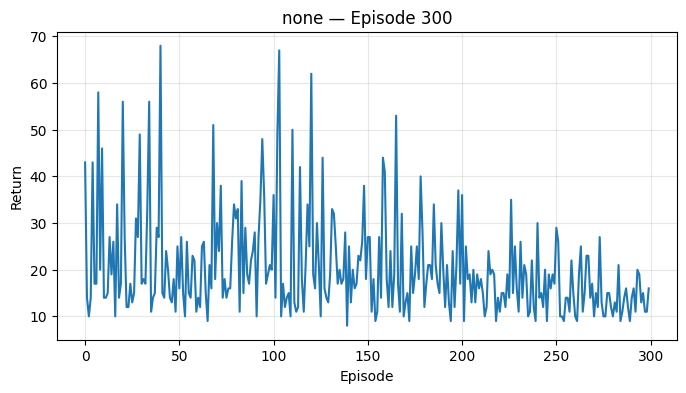

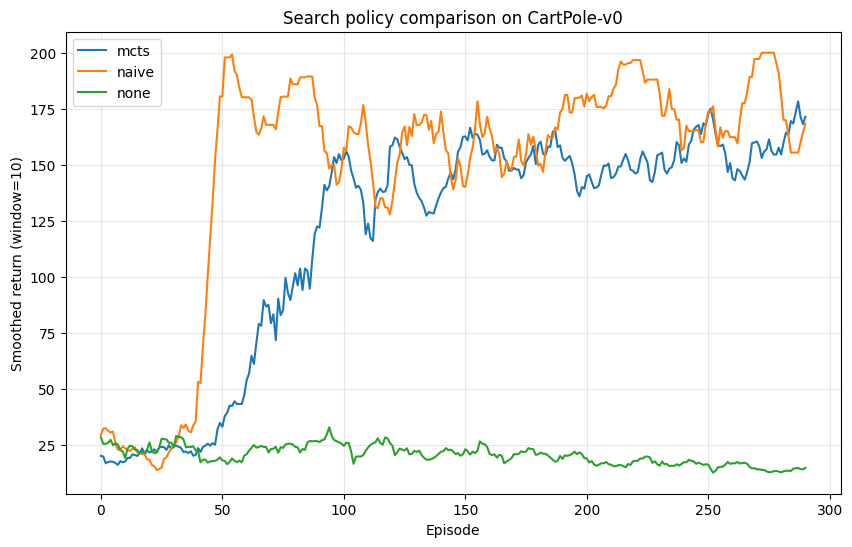

In [11]:
results = {}
for st in ["mcts", "naive", "none"]:
    # Reseed before each run so the three search types start from identical
    # network init / RNG state -> the comparison reflects the search, not luck.
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    print(f"\n=== Training agent with search_type = {st} ===")
    results[st] = train_agent(search_type=st, num_episodes=300, verbose=True)

plt.figure(figsize=(10, 6))
for st, returns in results.items():
    window = 10
    smoothed = np.convolve(returns, np.ones(window)/window, mode="valid")
    plt.plot(smoothed, label=st)
plt.title("Search policy comparison on CartPole-v0")
plt.xlabel("Episode")
plt.ylabel("Smoothed return (window=10)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Discussion Questions

The answers below report what the comparison run actually produced (see `figures/mcts_comparison.png`). CartPole-v0 caps an episode at 200.

1. **Which search method converges fastest, and why?**
In this run the naive depth search is the fastest to learn. Its smoothed return jumps from roughly 25 to near 200 at about episode 45 and then holds in the 150 to 200 band, whereas MCTS only begins to climb near episode 50 and settles into a steady 150 to 175 band by the end. No-search never leaves the 15 to 30 region (it finishes at a mean of about 13). The cause is the geometry of the task, not any weakness of MCTS. CartPole has a branching factor of two and we plan to depth three, so the brute-force planner enumerates only `2^3 = 8` trajectories and scores every one of them with the learned model. Once the dynamics and value heads are even roughly calibrated, that exhaustive lookahead commits to a good first action and hands the learner a confident, almost one-hot policy target, which is a strong supervisory signal. MCTS spends part of its 25-simulation budget on exploration (root Dirichlet noise and the PUCT exploration term) and on tree statistics that are noisy while priors and Q-values are still immature, so its visit-count target is softer early and it commits more slowly. This is exactly the regime the theory flags as favourable to naive depth search: a small action set and a shallow horizon, where the adaptive budgeting of MCTS has little structure to exploit and its bookkeeping is not yet amortised. No-search fails for a structural reason. With no planner the stored policy target is the prediction network's own output, so the cross-entropy term has nothing to pull the policy towards; the value targets alone cannot manufacture a competent policy, and the agent stays near its initialisation.

2. **Wall-clock cost per decision, and how it scales.**
Per action, no-search is a single network evaluation and is by far the cheapest. Naive search performs `O(|A|^d)` model calls, here only eight leaves plus the internal expansions, which is trivial for this task. MCTS performs `O(num_simulations)` sequential recurrent calls, twenty-five here, each followed by selection and back-up. On CartPole the naive planner is therefore both cheaper and faster to learn, which is why it wins outright. The scaling runs the other way, though: the naive cost grows exponentially with depth and with the number of actions, while the MCTS cost grows only linearly in the simulation budget and is spent selectively on promising branches. For a large branching factor or a long horizon, enumeration becomes intractable and MCTS is the only practical option.

3. **Effect of increasing `num_simulations`.**
More simulations sharpen the visit-count distribution and lower the variance of both the chosen action and the policy target, which improves sample efficiency up to a point. On CartPole that point arrives early, since MCTS already reaches a band comparable to the naive planner; past it, extra simulations mostly buy wall-clock for a near-identical decision. There is also a failure mode worth naming for a robotics setting: when the learned model is biased, a larger or deeper search compounds that bias by trusting imagined transitions further into the future, so more search can hurt rather than help until the model itself is accurate.

4. **Why MuZero works without ever reconstructing observations.**
MuZero never decodes its latent back into an observation. The latent only needs to be sufficient to predict the quantities that drive control, namely reward, value, and policy, and the three networks are trained jointly so that the learned latent dynamics are value-equivalent to the true environment. Planning in that latent space yields the same action choices that planning in the real MDP would, even though the latent carries no pixel-level or state-level interpretation. It is the same principle as a learned state estimator in robotics: the representation is judged by whether it supports good decisions, not by whether it can redraw the scene.

5. **What it would take to scale to a harder environment (LunarLander or Atari).**
The representation network needs the most work: a convolutional or otherwise structured encoder for high-dimensional or image observations, on top of the frame stacking already present. The latent and the dynamics network need more capacity, typically residual blocks, and the value and reward heads need the categorical support and the invertible scaling transform that MuZero uses to handle a wide range of magnitudes. The planner needs a larger simulation budget and retuned PUCT constants, and training benefits from prioritised replay and the Reanalyse mechanism that recomputes targets with the current model. The search machinery itself, namely selection, expansion, back-up, and the PUCT rule, carries over essentially unchanged.


## ✅ Submission Checklist

Before submitting, make sure:

- [ ] All `TODO` blocks are filled in.
- [ ] The networks (`RepresentationNet`, `DynamicsNet`, `PredictionNet`) instantiate without errors.
- [ ] `MCTS.run(...)` returns visit counts whose sum equals `num_simulations`.
- [ ] `naive_depth_search(...)` returns a valid action (`int`) and a finite value.
- [ ] `train_agent(search_type="mcts")` runs end-to-end and produces a non-trivial learning curve.
- [ ] All three search types are compared in the final plot.
- [ ] The discussion questions are answered.

Good luck! 🌳